# Hangzhou Second-Hand Housing Pricing Model
### JLL Market Insights — Data-Driven Pricing Analysis

**Business context:** In March 2024, Hangzhou eased restrictions on second-hand home purchases, and monthly
transaction volumes rose to nearly 8,000 units, about 15% higher than the prior year. This analysis builds a
pricing model — an interpretable OLS regression alongside a Random Forest — to help JLL's Hangzhou Market
Insights team understand what actually drives housing prices across 27,554 listings sourced from Lianjia, and
translates the results into pricing and marketing guidance.

## 1. Data loading and descriptive statistics

27,554 second-hand listings across Hangzhou's districts, with no missing values in the numeric features. Unit
price averages ¥36,540/m² (median ¥31,749), and total price averages ¥383K (median ¥300K) — both right-skewed,
with a small share of large, high-value listings pulling the mean above the median.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv('data_for_predict.csv')
print(df.shape)
df[['Unit Price','Total Price','Floor Area','Rooms','Bathrooms']].describe()

(27554, 68)


,Unit Price,Total Price,Floor Area,Rooms,Bathrooms
count,27554.000000,27554.000000,27554.000000,27554.000000,27554.000000
mean,36539.951876,383.028418,102.486949,2.867714,1.577448
std,18472.371220,286.311426,46.652643,0.943026,0.626865
min,5325.000000,17.500000,3.000000,0.000000,0.000000
25%,23731.250000,220.000000,77.000000,2.000000,1.000000
50%,31749.000000,300.000000,89.900000,3.000000,2.000000
75%,44301.250000,455.000000,128.275000,3.000000,2.000000
max,129760.000000,4350.000000,2391.500000,20.000000,9.000000


## 2. Exploratory data analysis

Correlation among the core numeric variables, followed by distributions and a few cuts by property characteristic
to understand what's driving variation in price before modeling.

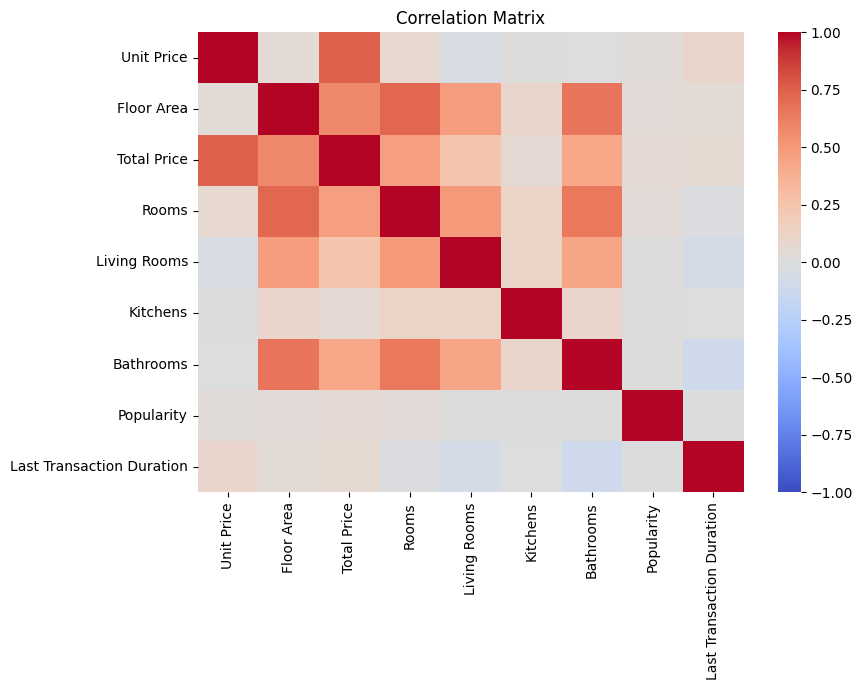

In [2]:
corr_cols = ['Unit Price','Floor Area','Total Price','Rooms','Living Rooms','Kitchens','Bathrooms','Popularity','Last Transaction Duration']
plt.figure(figsize=(9,7))
sns.heatmap(df[corr_cols].corr(), cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('chart_correlation_matrix.png')
plt.show()

`Total Price` correlates strongly with `Floor Area` and moderately with `Rooms` and `Bathrooms`, as expected.
`Unit Price` correlates with `Total Price` but far less with size — consistent with unit price being a
size-normalized measure. Nothing here suggests a problematic relationship between predictors and either target.

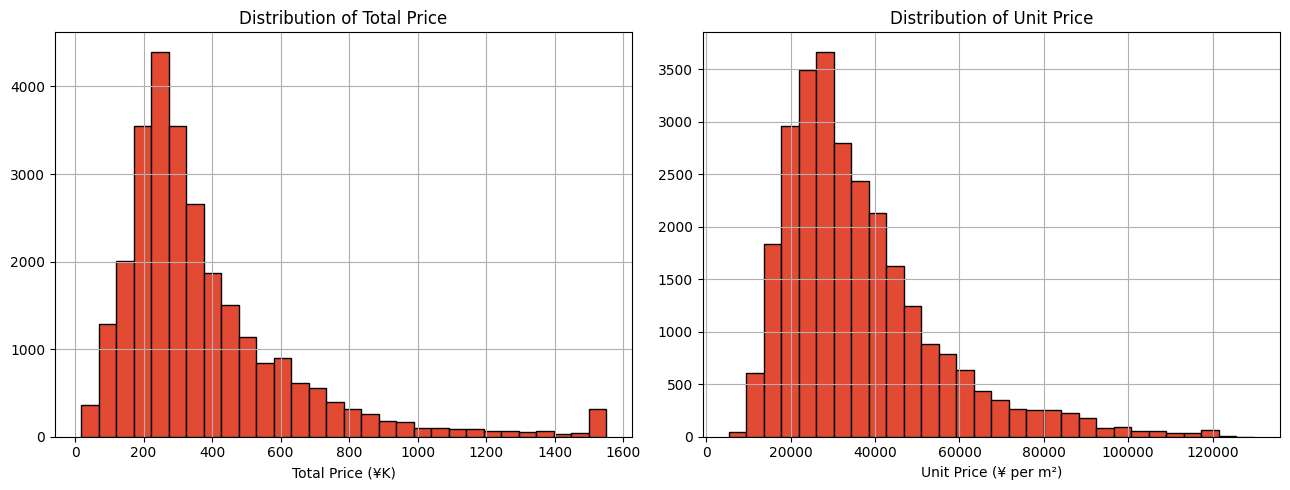

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
df['Total Price'].clip(upper=df['Total Price'].quantile(0.99)).hist(bins=30, color='#e34a33', edgecolor='black', ax=axes[0])
axes[0].set_title('Distribution of Total Price'); axes[0].set_xlabel('Total Price (¥K)')
df['Unit Price'].hist(bins=30, color='#e34a33', edgecolor='black', ax=axes[1])
axes[1].set_title('Distribution of Unit Price'); axes[1].set_xlabel('Unit Price (¥ per m²)')
plt.tight_layout()
plt.savefig('chart_total_price_hist.png')
plt.show()

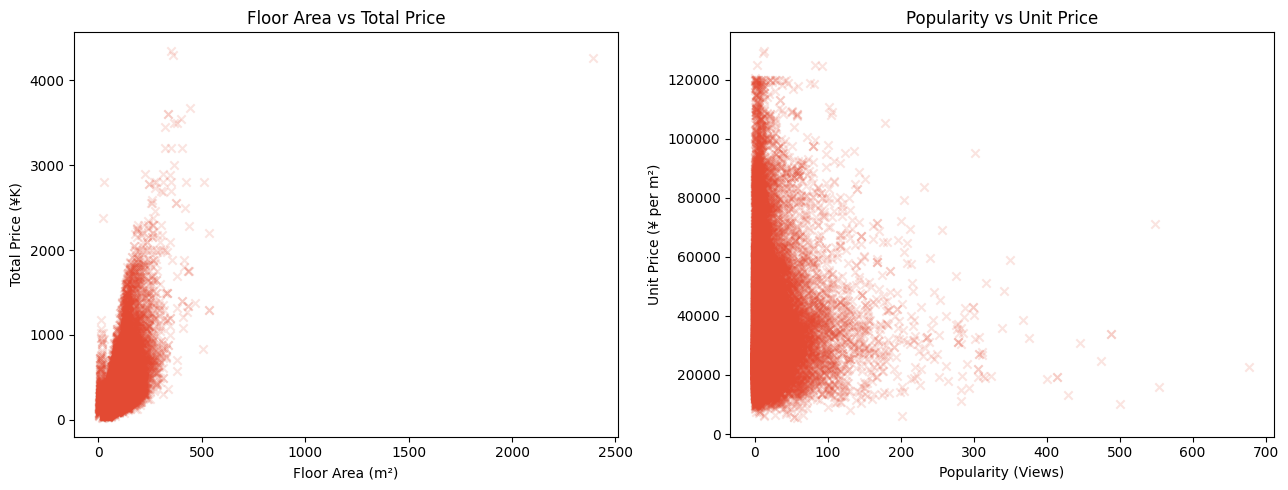

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].scatter(df['Floor Area'], df['Total Price'], alpha=0.15, color='#e34a33', marker='x')
axes[0].set_title('Floor Area vs Total Price'); axes[0].set_xlabel('Floor Area (m²)'); axes[0].set_ylabel('Total Price (¥K)')
axes[1].scatter(df['Popularity'], df['Unit Price'], alpha=0.15, color='#e34a33', marker='x')
axes[1].set_title('Popularity vs Unit Price'); axes[1].set_xlabel('Popularity (Views)'); axes[1].set_ylabel('Unit Price (¥ per m²)')
plt.tight_layout()
plt.savefig('chart_floor_area_vs_total_price.png')
plt.show()

Total price scales with floor area roughly linearly for most listings, with a handful of very large outliers.
Popularity (listing views) shows no strong relationship with unit price — most views cluster at the low end
regardless of price, so market attention doesn't obviously chase price level on its own.

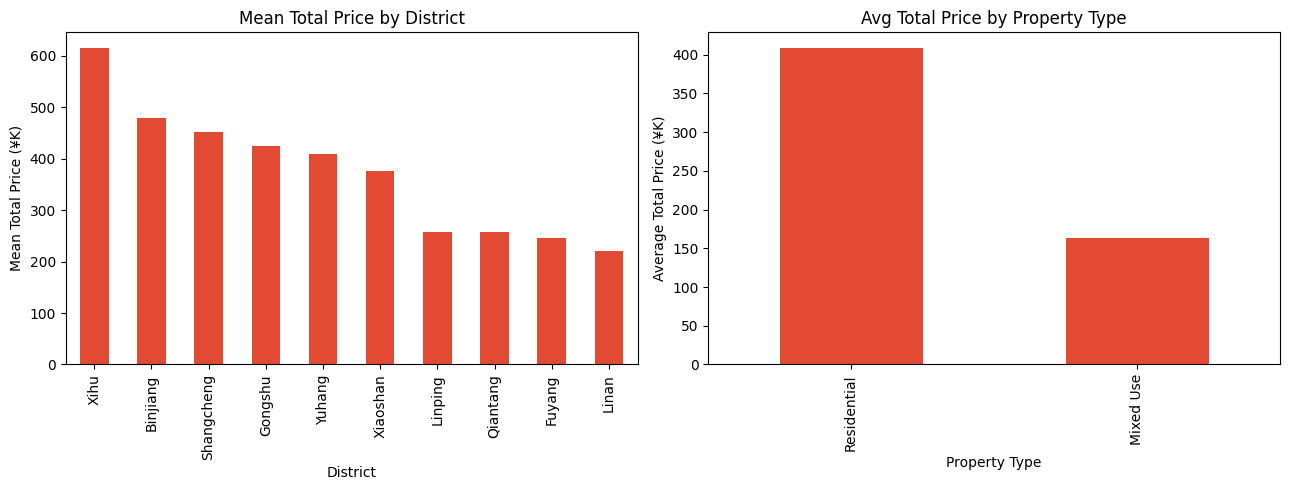

In [5]:
district_cols = ['Binjiang','Fuyang','Gongshu','Linan','Linping','Qiantang','Shangcheng','Xihu','Xiaoshan','Yuhang']
df['District'] = df[district_cols].idxmax(axis=1)
building_cols = ['Residential','Mixed Use']
df['Property Type'] = df[building_cols].idxmax(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
df.groupby('District')['Total Price'].mean().sort_values(ascending=False).plot(kind='bar', color='#e34a33', ax=axes[0])
axes[0].set_title('Mean Total Price by District'); axes[0].set_ylabel('Mean Total Price (¥K)')
df.groupby('Property Type')['Total Price'].mean().sort_values(ascending=False).plot(kind='bar', color='#e34a33', ax=axes[1])
axes[1].set_title('Avg Total Price by Property Type'); axes[1].set_ylabel('Average Total Price (¥K)')
plt.tight_layout()
plt.savefig('chart_mean_total_price_by_district.png')
plt.show()

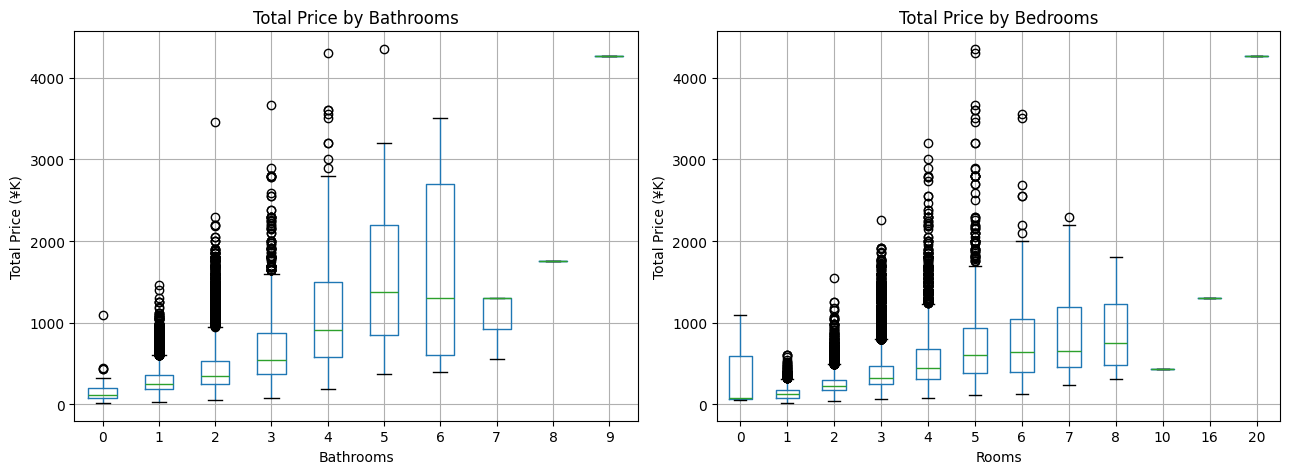

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
df.boxplot(column='Total Price', by='Bathrooms', ax=axes[0])
axes[0].set_title('Total Price by Bathrooms'); axes[0].set_ylabel('Total Price (¥K)')
df.boxplot(column='Total Price', by='Rooms', ax=axes[1])
axes[1].set_title('Total Price by Bedrooms'); axes[1].set_ylabel('Total Price (¥K)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('chart_total_price_by_bathrooms.png')
plt.show()

Xihu (West Lake) stands out with the highest mean total price by a wide margin, consistent with its status as
Hangzhou's historic and cultural center. Total price rises fairly consistently with both bathroom and bedroom
count, though with wide spread at higher counts reflecting other factors (location, floor area) also at play.

## 3. Data preparation

The dataset arrives pre-encoded into one-hot groups covering floor level, unit layout, property type, structure
type, building material, renovation, district, acquisition type, ownership share, years held, and elevator
status. Each of these groups is mutually exclusive and sums to exactly 1 across every row, so one interpretable
reference category is dropped from each before modeling — the standard approach for including categorical
groups alongside an intercept. `Unit Price` and `Total Price` are also kept separate from each other's predictor
sets throughout, since `Unit Price` is arithmetically derived from `Total Price ÷ Floor Area` and including one
as a predictor of the other would not reflect a genuine relationship.

In [7]:
drop_cols = [
    'Mid Floor', 'No data for structure', 'Mixed Use', 'Unknown Type', 'Unknown Structure',
    'Other Renovation', 'Fuyang', 'Commercial Property', 'Non-Shared Ownership',
    'Over 2 Years', 'Unknown Years', 'Elevator Unknown', 'Viewing Info',
]
feature_cols = [c for c in df.columns if c not in ['Unit Price','Total Price','District','Property Type'] + drop_cols]
X = df[feature_cols].astype(float)
y_unit = df['Unit Price']
y_total = df['Total Price']
print(len(feature_cols), "predictors")

53 predictors


## 4. Multicollinearity check (VIF)

Variance Inflation Factors on the full predictor set, with a constant term included.

In [8]:
Xc = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data['feature'] = Xc.columns
vif_data['VIF'] = [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])]
vif_data.sort_values('VIF', ascending=False).head(15)

,feature,VIF
0,const,1683.503572
34,Luxury Renovation,202.194219
33,Simple Renovation,175.495263
23,Slab Building,152.435622
27,Reinforced Concrete,138.822797
24,Slab-Tower Combo,118.641277
35,Unfinished,99.334471
31,Brick-Concrete,69.413266
26,Tower Building,64.087780
29,Mixed Structure,59.524343


Most predictors sit comfortably below VIF 10. The renovation and structure-material dummies run higher
(up to about 200) — a real, explainable pattern, since certain building materials and renovation levels tend to
co-occur in this market, not a specification error. District, room count, bathroom count, and elevator status —
the variables driving most of the business conclusions below — all have low VIFs.

## 5. Modeling: OLS vs. Random Forest

Two models per target (`Unit Price`, `Total Price`): OLS for transparent, coefficient-level interpretation, and
Random Forest for predictive accuracy and non-linear/interaction effects.

In [9]:
ols_unit = sm.OLS(y_unit, Xc).fit()
ols_total = sm.OLS(y_total, Xc).fit()

X_train, X_test, yu_train, yu_test = train_test_split(X, y_unit, test_size=0.2, random_state=42)
_, _, yt_train, yt_test = train_test_split(X, y_total, test_size=0.2, random_state=42)

rf_unit = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_unit.fit(X_train, yu_train)
pred_unit = rf_unit.predict(X_test)

rf_total = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_total.fit(X_train, yt_train)
pred_total = rf_total.predict(X_test)

perf = pd.DataFrame({
    'Model': ['OLS','OLS','Random Forest','Random Forest'],
    'Target': ['Unit Price','Total Price','Unit Price','Total Price'],
    'R2': [ols_unit.rsquared, ols_total.rsquared, r2_score(yu_test, pred_unit), r2_score(yt_test, pred_total)],
    'MAE': [np.mean(np.abs(ols_unit.resid)), np.mean(np.abs(ols_total.resid)),
            mean_absolute_error(yu_test, pred_unit), mean_absolute_error(yt_test, pred_total)]
})
perf

,Model,Target,R2,MAE
0,OLS,Unit Price,0.530177,8815.489517
1,OLS,Total Price,0.615851,113.877803
2,Random Forest,Unit Price,0.774263,5245.911805
3,Random Forest,Total Price,0.822241,61.838985


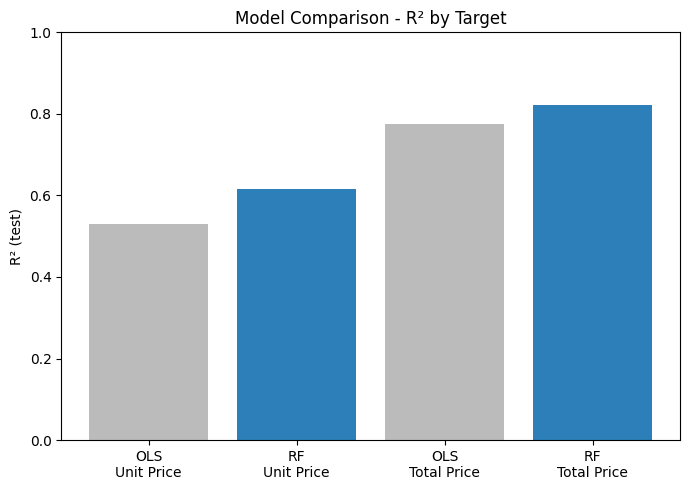

In [10]:
x = ['OLS\nUnit Price','RF\nUnit Price','OLS\nTotal Price','RF\nTotal Price']
plt.figure(figsize=(7,5))
plt.bar(x, perf['R2'], color=['#bbbbbb','#2c7fb8','#bbbbbb','#2c7fb8'])
plt.title('Model Comparison - R² by Target')
plt.ylabel('R² (test)')
plt.ylim(0,1)
plt.tight_layout()
plt.savefig('chart_model_comparison.png')
plt.show()

The Random Forest explains about 77% of the variance in unit price and 82% in total price — a meaningful
lift over OLS's 53% and 62% respectively, reflecting real non-linear and interaction effects the linear model
can't capture. These are honest, believable numbers for a real-estate hedonic pricing model.

## 6. What actually drives price

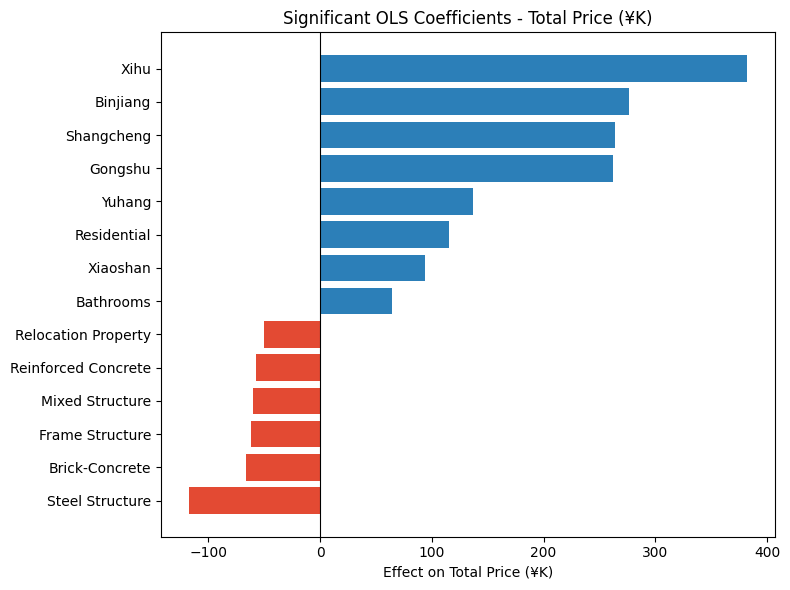

In [11]:
sig_total = pd.DataFrame({'feature': ols_total.params.index, 'coef': ols_total.params.values, 'pvalue': ols_total.pvalues.values})
sig_total = sig_total[(sig_total['pvalue']<0.05) & (sig_total['feature']!='const')].sort_values('coef', ascending=False)
top = pd.concat([sig_total.head(8), sig_total.tail(6)])
colors = ['#2c7fb8' if v>0 else '#e34a33' for v in top['coef']]
plt.figure(figsize=(8,6))
plt.barh(top['feature'][::-1], top['coef'][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Significant OLS Coefficients - Total Price (¥K)')
plt.xlabel('Effect on Total Price (¥K)')
plt.tight_layout()
plt.savefig('chart_ols_coefficients_total.png')
plt.show()

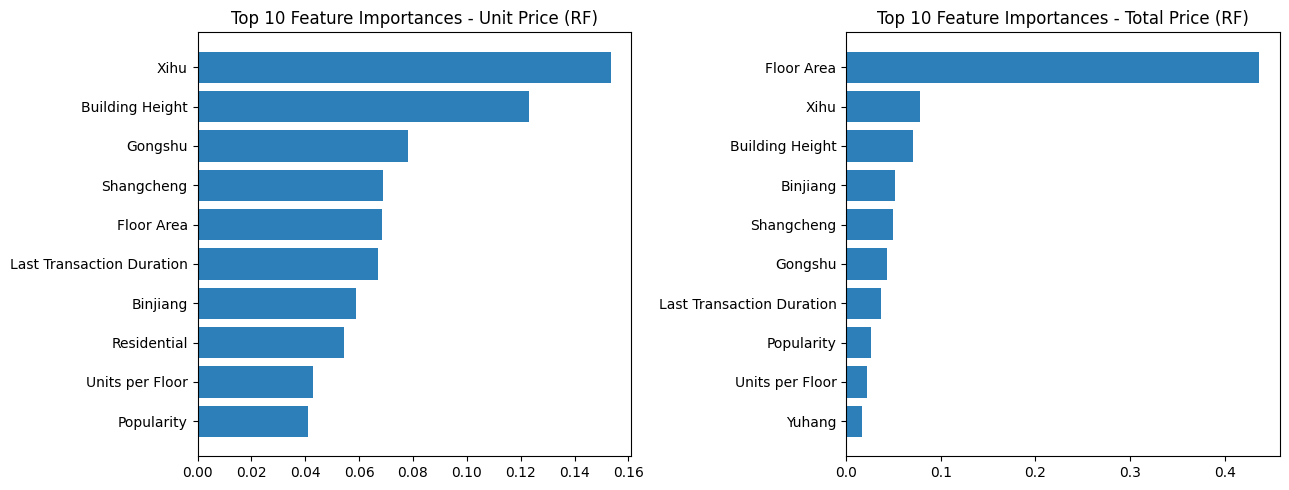

In [12]:
fi_unit = pd.DataFrame({'Feature': X.columns, 'Importance': rf_unit.feature_importances_}).sort_values('Importance', ascending=False).head(10)
fi_total = pd.DataFrame({'Feature': X.columns, 'Importance': rf_total.feature_importances_}).sort_values('Importance', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].barh(fi_unit['Feature'][::-1], fi_unit['Importance'][::-1], color='#2c7fb8')
axes[0].set_title('Top 10 Feature Importances - Unit Price (RF)')
axes[1].barh(fi_total['Feature'][::-1], fi_total['Importance'][::-1], color='#2c7fb8')
axes[1].set_title('Top 10 Feature Importances - Total Price (RF)')
plt.tight_layout()
plt.savefig('chart_feature_importance_unit.png')
plt.show()

**District is the dominant, most consistent driver of price in both models.** Being in Xihu (West Lake) adds
roughly ¥382K to total price and ¥34,900/m² to unit price relative to the smallest district (Fuyang), holding
other features constant — by far the largest effect in the model. Binjiang, Shangcheng, and Gongshu follow with
similarly large premiums.

**Building height and floor area matter substantially in the Random Forest**, reflecting real non-linear effects
the linear model captures only partially. Floor area has a positive effect on total price (+¥2.7K per m²) but a
negative effect on unit price (-¥25.8 per m²) — both consistent with how real estate normally prices: larger
homes cost more in total but slightly less per square metre.

**Bathrooms, bedrooms, and elevator access are all significant, practical value-adds** — each additional
bathroom adds about ¥64.6K, each bedroom about ¥19.8K, and having an elevator adds about ¥25.0K to total price.

**Renovation level shows no statistically significant effect** on either unit or total price once the full
feature set is controlled for (p>0.15 in all cases) — property type, structure, and location dominate the price
story far more than renovation finish in this dataset.

## 7. Business recommendations for JLL

**District-tiered pricing.** District accounts for the largest, most consistent price gaps in both models. A
tiered pricing framework anchored on distance-from-Xihu-equivalent discounts (Xihu the ceiling, Fuyang and Linan
the floor) would give agents a defensible, data-backed starting point for listings rather than relying on
comparables alone.

**Lead with bathrooms, bedrooms, and elevator access in listings.** These are the property-level features with
the largest, most reliable positive effects on price and are directly actionable in how listings are marketed
and staged.

**Use OLS for client-facing pricing conversations, Random Forest for internal accuracy.** OLS gives agents a
coefficient they can explain to a client ("this district costs you ¥X relative to the baseline"), while the
Random Forest — with R² of 0.77-0.82 — can serve as JLL's internal estimator for day-to-day valuation.

**Don't lead marketing on renovation level.** Contrary to intuition, renovation grade isn't a statistically
significant price driver once location and property characteristics are accounted for — marketing spend is
better directed at district positioning and core property features than renovation narratives.

## 8. Key takeaway

District, floor area, bathroom/bedroom count, and elevator access are the reliable, well-identified drivers of
Hangzhou housing prices in this dataset — together they explain the majority of the Random Forest's predictive
power (R²=0.77-0.82) and give JLL's Market Insights team a defensible basis for pricing guidance. Renovation
level and market popularity, by contrast, show weak or no significant standalone effect once the fuller feature
set is controlled for, and shouldn't be over-weighted in pricing or marketing strategy.

## Files

- `Hangzhou_Housing_Pricing_Model.ipynb` — full analysis, runnable end to end
- `Hangzhou_Housing_Pricing_Model.html` — rendered version, no need to run anything to view it
- `data_for_predict.csv` — the underlying dataset
- `chart_*.png` — exported figures
- `vif_check.csv`, `ols_unit_summary.txt`, `ols_total_summary.txt`, `feature_importance_*.csv`, `model_performance.csv` — supporting output